In [1]:
%cp -r ../resources .

In [2]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from Astrid.data_processing import get_weights
from Astrid.config import MC_FILENAMES, PARAMS, PARAMETER_NAMES
from Astrid.effective_area import bin_edges_to_centers, bin_centers_to_edges
import data_loader
import weighter
import weighter_original
import binning
import fc
import gc


Segmented flux normalizations from table X with corresponding normalizations.

In [4]:
energy_edges_MESE = [1.0, 2.15, 4.64, 10.0, 21.5, 46.4, 100.0, 215.4, 464.2, 1000.0, 2154.4, 4641.6, 10000.0, 100000.0]
energy_centers_MESE = [1.47, 3.16, 6.81, 14.7, 31.6, 68.1, 146.8, 316.2, 681.3, 1467.8, 3162.3, 6812.9, 31622.8]


norm_segmented = [0.0, 5.4, 3.9, 4.41, 5.51, 3.34, 1.55, 0.31, 0.59, 0.327, 0.0, 0.25, 0.0]
sigma_upper = [5.2, 5.8, 2.1, 0.93, 0.72, 0.63, 0.50, 0.33, 0.42, 0.32, 0.19, 0.24, 0.76]
sigma_lower = [0.0, 5.4, 2.0, 0.90, 0.66, 0.52, 0.35, 0.31, 0.23, 0.059, 0.0, 0.16, 0.0]

energy_edges_MESE = np.asarray(energy_edges_MESE)
energy_centers_MESE = np.asarray(energy_centers_MESE)
energy_edges_MESE *= 1e3 # GeV
energy_centers_MESE *= 1e3 # GeV
print(energy_edges_MESE)

norm_segmented = np.asarray(norm_segmented)
sigma_upper = np.asarray(sigma_upper)
sigma_lower = np.asarray(sigma_lower)

norm_segmented *= 1e-8 # GeV^-1 * cm^-2 * s^-1 * sr^-1
sigma_upper *= 1e-8 # GeV^-1 * cm^-2 * s^-1 * sr^-1
sigma_lower *= 1e-8 # GeV^-1 * cm^-2 * s^-1 * sr^-1



[1.0000e+03 2.1500e+03 4.6400e+03 1.0000e+04 2.1500e+04 4.6400e+04
 1.0000e+05 2.1540e+05 4.6420e+05 1.0000e+06 2.1544e+06 4.6416e+06
 1.0000e+07 1.0000e+08]


<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1116/333194404.py:18: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$E^2 \phi$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
/tmp/ipykernel_1116/333194404.py:1: RuntimeWarning: divide by zero encountered in log
  log_flux = np.log(norm_segmented)
/tmp/ipykernel_1116/333194404.py:3: RuntimeWarning: divide by zero encountered in divide
  sigma_upper_log = np.log(1 + sigma_upper / norm_segmented)
/tmp/ipykernel_1116/333194404.py:4: RuntimeWarning: invalid value encountered in divide
  sigma_lower_log = np.log(1 + sigma_lower / norm_segmented)


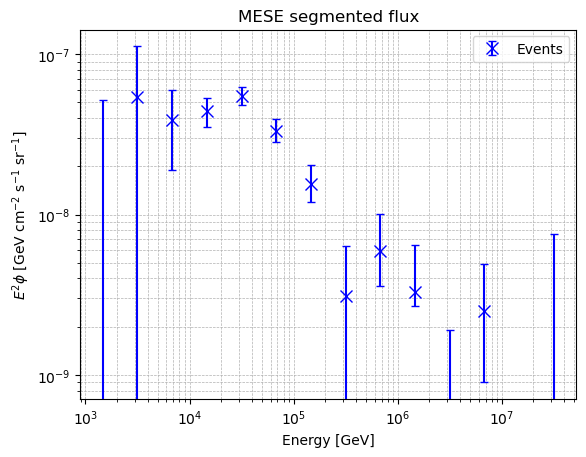

In [19]:
log_flux = np.log(norm_segmented)

sigma_upper_log = np.log(1 + sigma_upper / norm_segmented)
sigma_lower_log = np.log(1 + sigma_lower / norm_segmented)



conversion = 1e6 # Energy in TeV and flux norm in 1e-18 * GeV^-1 *.....



plt.errorbar(energy_centers_MESE, norm_segmented, 
             yerr=[sigma_lower, sigma_upper], 
             fmt='x', color='blue', label='Events', capsize=3, markersize=8, linestyle='none')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('$E^2 \phi$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.title('MESE segmented flux')
plt.legend()
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.5)
plt.show()


In [3]:
energy_bins = np.logspace(4, 7, 3*20+1)
energy_bins_low_resolution = np.logspace(4, 7, 20+1)
bin_centers = bin_edges_to_centers(energy_bins)
bin_centers_low_resolution = bin_edges_to_centers(energy_bins_low_resolution)

livetime_75 = 227708167.68      # The exact amount of time that HESE was running for the 7.5 year dataset
livetime12 = 12 * 365 * 24 * 3600
params_dict = dict(zip(PARAMETER_NAMES, PARAMS))
print(params_dict)

{'cr_delta_gamma': -0.05309302, 'nunubar_ratio': 0.99815326, 'anisotropy_scale': 1.000683, 'astro_gamma': 2.87375956, 'astro_norm': 6.36488608, 'conv_norm': 1.00621679, 'epsilon_dom': 0.95192328, 'epsilon_head_on': -0.0548763, 'muon_norm': 1.18706341, 'kpi_ratio': 1.00013744, 'prompt_norm': 0.0}


In [4]:
mc = data_loader.load_mc(MC_FILENAMES, emin=energy_bins[0], emax=energy_bins[-1])
data7 = data_loader.load_data("/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/resources/data/HESE_data.json", emin=energy_bins[0], emax=energy_bins[-1])
data12 = data_loader.load_data("/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/resources/data/HESE12_data.json", emin=energy_bins[0], emax=energy_bins[-1])

In [5]:
#sorted_mc, mc_bin_slices = binning.bin_data(mc)

# Sets up the Weighter class, that manages all the weight calculations
# Pass model type to weighter
weight_maker = weighter_original.Weighter(mc, model='spl')

In [23]:
# Best fits from running HESE_fit.py for both datasets with SPL model

"""HESE12_bestfit_params = [-0.02251703,  1.00557049,  0.98491038,  2.88035682,  8.97087434,
        1.26438946,  1.02344328,  0.0343498 ,  1.42268875,  1.01627587,
        0.  , 0.      ]"""  # Detta var när jag använde livetime för 7.5 år
HESE12_bestfit_params = [-0.00966812,  1.00069936,  0.98456953,  2.85928347,  5.16604078,
        1.12043262,  1.00841331,  0.03957451,  1.36822152,  1.00623763,
        0.  , 0.      ]

HESE7_bestfit_params = [-6.16946875e-03,  9.99539248e-01,  1.00089012e+00,  2.87614012e+00,
        6.47103067e+00,  1.05309841e+00,  9.55277154e-01, -4.97442491e-02,
        1.18712287e+00,  1.00268809e+00,  0.00000000e+00, 0.]
parameter_names = [
    "cr_delta_gamma",
    "nunubar_ratio",
    "anisotropy_scale",
    "astro_gamma",
    "astro_norm",
    "conv_norm",
    "epsilon_dom",
    "epsilon_head_on",
    "muon_norm",
    "kpi_ratio",
    "prompt_norm",
    'cutoff_energy'
]

weights12 = weight_maker.get_weights(livetime_75, parameter_names, HESE12_bestfit_params)
weights7 = weight_maker.get_weights(livetime_75, parameter_names, HESE7_bestfit_params)




Using SPL model


Using SPL model


819370


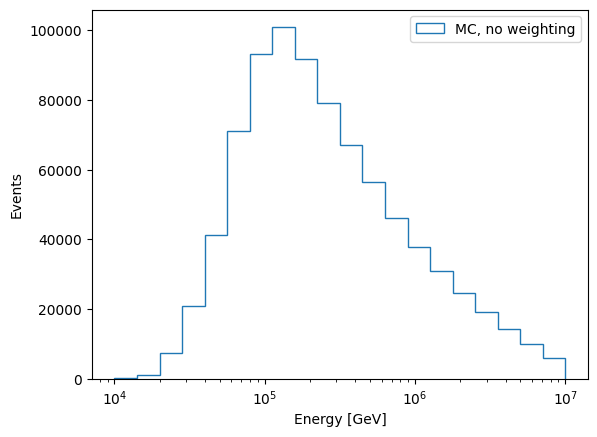

In [16]:
print(len(mc))

plt.hist(mc['recoDepositedEnergy'], bins=energy_bins_low_resolution, histtype='step', label='MC, no weighting')
plt.xscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Events')
plt.legend()
plt.show()


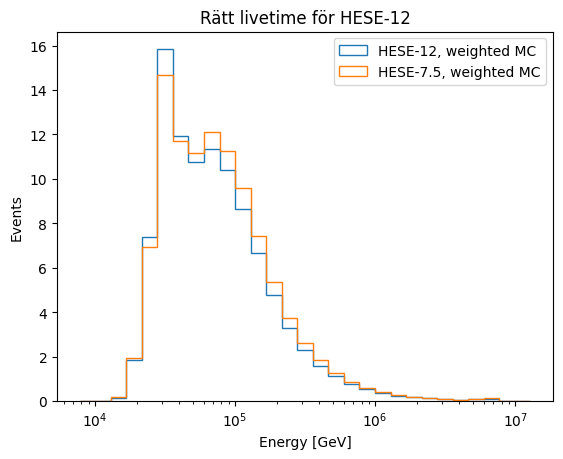

In [24]:
plt.hist(mc['recoDepositedEnergy'], bins=e_edges, weights=weights12[0], histtype='step', label='HESE-12, weighted MC')
plt.hist(mc['recoDepositedEnergy'], bins=e_edges, weights=weights7[0], histtype='step', label='HESE-7.5, weighted MC')
#plt.hist(data12['recoDepositedEnergy'], bins=e_edges, histtype='step', label='HESE-12, data', linestyle='--', color='blue')
#plt.hist(data7['recoDepositedEnergy'], bins=e_edges, histtype='step', label='HESE-7.5, data', linestyle='--', color='orange')
plt.xscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Events')
plt.title('Rätt livetime för HESE-12')
plt.legend()
plt.show()


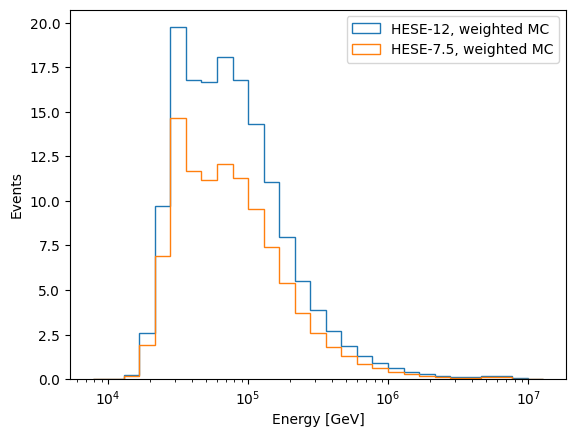

In [21]:
e_edges, _, _ = binning.get_bins(emin=10.0e3)
bin_centers = 10.0 ** (0.5 * (np.log10(e_edges[:-1]) + np.log10(e_edges[1:])))
binned_mc, _ = np.histogram(mc['recoDepositedEnergy'], bins=e_edges)

#print(len(weights12[0]))

plt.hist(mc['recoDepositedEnergy'], bins=e_edges, weights=weights12[0], histtype='step', label='HESE-12, weighted MC')
plt.hist(mc['recoDepositedEnergy'], bins=e_edges, weights=weights7[0], histtype='step', label='HESE-7.5, weighted MC')
#plt.hist(data12['recoDepositedEnergy'], bins=e_edges, histtype='step', label='HESE-12, data', linestyle='--', color='blue')
#plt.hist(data7['recoDepositedEnergy'], bins=e_edges, histtype='step', label='HESE-7.5, data', linestyle='--', color='orange')
plt.xscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Events')
plt.legend()
plt.show()



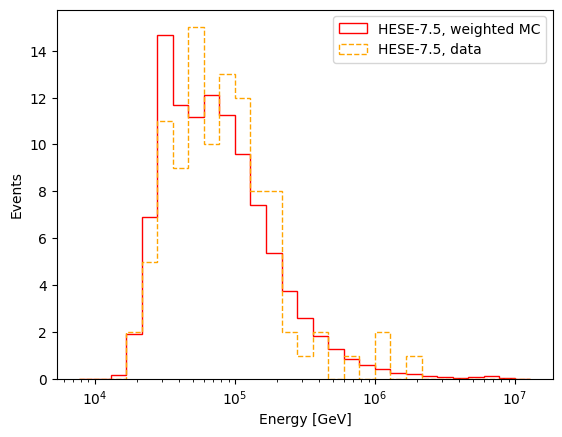

In [20]:
plt.hist(mc['recoDepositedEnergy'], bins=e_edges, weights=weights7[0], histtype='step', label='HESE-7.5, weighted MC', color='red')
plt.hist(data7['recoDepositedEnergy'], bins=e_edges, histtype='step', label='HESE-7.5, data', linestyle='--', color='orange')
plt.xscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Events')
plt.legend()
plt.show()

In [ ]:
sorted_data, data_bin_slices = binning.bin_data(data7)

# Counts the number of events in each analysis bin, to give the total observed
# events in each bin
binned_data = np.array([len(sorted_data[data_bin]) for data_bin in data_bin_slices])


In [32]:
weight_maker_nuSIprop = weighter.Weighter(sorted_mc, nuSIprop=True)

In [33]:
binned_mc_nuSIprop, _ = np.histogram(mc['recoDepositedEnergy'], bins=e_edges)

for i, N in enumerate(binned_mc_nuSIprop):
    if N == binned_mc[i]:
        pass
    else:
        print(i, N, binned_mc[i])




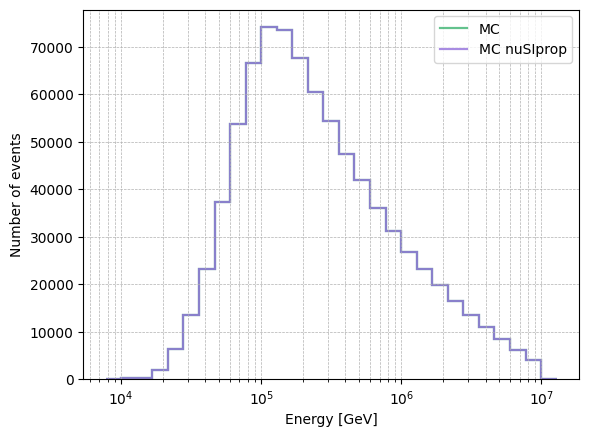

In [ ]:
e_edges, _, _ = binning.get_bins(emin=10.0e3)
bin_centers = 10.0 ** (0.5 * (np.log10(e_edges[:-1]) + np.log10(e_edges[1:])))
binned_mc, _ = np.histogram(mc['recoDepositedEnergy'], bins=e_edges)

plt.stairs(binned_mc, e_edges, label='MC', color='mediumseagreen', linewidth=1.6, alpha=0.8)
#plt.stairs(binned_mc_nuSIprop, e_edges, label='MC nuSIprop', color='mediumpurple', linewidth=1.6, alpha=0.8)
plt.xscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
plt.legend()
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.5)
plt.show()

In [6]:
weight_maker = weighter.Weighter(mc)

In [7]:
mc_cascade = mc[mc['recoMorphology'] == 0]
weight_maker_cascade = weighter.Weighter(mc_cascade)
gc.collect()

mc_track = mc[mc['recoMorphology'] == 1]
weight_maker_track = weighter.Weighter(mc_track)
gc.collect()

mc_dcascade = mc[mc['recoMorphology'] == 2]
weight_maker_dcascade = weighter.Weighter(mc_dcascade)
gc.collect()


0

Total cascade events: 113.12608582776713
Total track events: 57.48462910320671
Total dcascade events: 4.906829064826898


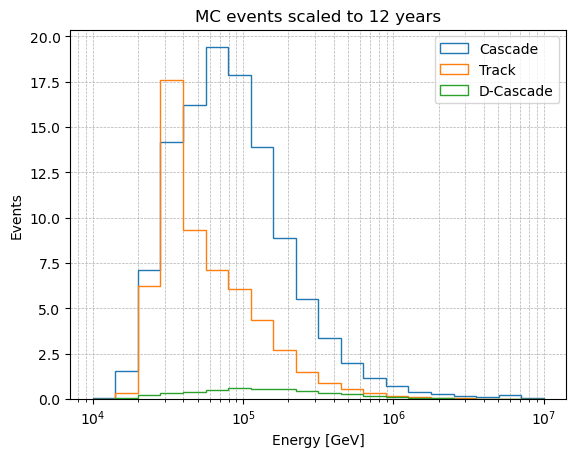

In [12]:
# Get weights for cascade, track, and dcascade. Signal + Background.
p_copy = params_dict.copy()


cascade_weights = weight_maker_cascade.get_weights(livetime12, p_copy.keys(), p_copy.values())[0]
cascade_events, _ = np.histogram(mc_cascade['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=cascade_weights)
print('Total cascade events:', np.sum(cascade_weights))
gc.collect()


track_weights = weight_maker_track.get_weights(livetime12, p_copy.keys(), p_copy.values())[0]
track_events, _ = np.histogram(mc_track['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=track_weights)
print('Total track events:', np.sum(track_weights))


dcascade_weights = weight_maker_dcascade.get_weights(livetime12, p_copy.keys(), p_copy.values())[0]
dcascade_events, _ = np.histogram(mc_dcascade['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=dcascade_weights)
print('Total dcascade events:', np.sum(dcascade_weights))

plt.hist(mc_cascade['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=cascade_weights, histtype='step', label='Cascade')
plt.hist(mc_track['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=track_weights, histtype='step', label='Track')
plt.hist(mc_dcascade['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=dcascade_weights, histtype='step', label='D-Cascade')
plt.xscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Events')
plt.title('MC events scaled to 12 years')
plt.legend()
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.5)
plt.show()


Total cascade events: 20.82110159900834
Total track events: 39.137880481360575
Total dcascade events: 0.6471131519465909


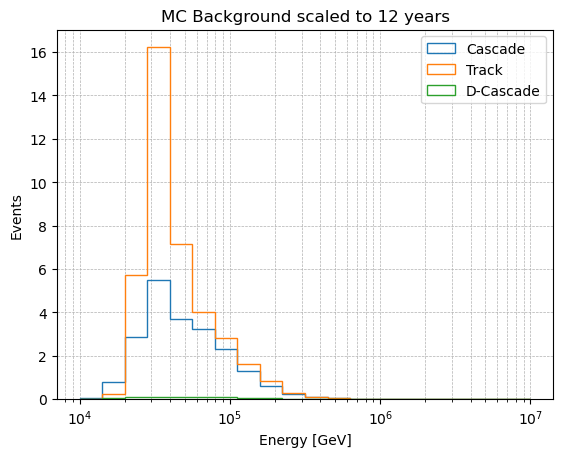

In [11]:
# Get weights for cascade, track, and dcascade. Background only.
p_copy = params_dict.copy()
p_copy["astro_norm"] = 0.0

cascade_weights_background = weight_maker_cascade.get_weights(livetime12, p_copy.keys(), p_copy.values())[0]
cascade_events_background, _ = np.histogram(mc_cascade['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=cascade_weights_background)
print('Total cascade events:', np.sum(cascade_events_background))
gc.collect()

track_weights_background = weight_maker_track.get_weights(livetime12, p_copy.keys(), p_copy.values())[0]
track_events_background, _ = np.histogram(mc_track['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=track_weights_background)
print('Total track events:', np.sum(track_events_background))
gc.collect()

dcascade_weights_background = weight_maker_dcascade.get_weights(livetime12, p_copy.keys(), p_copy.values())[0]
dcascade_events_background, _ = np.histogram(mc_dcascade['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=dcascade_weights_background)
print('Total dcascade events:', np.sum(dcascade_events_background))
gc.collect()

plt.hist(mc_cascade['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=cascade_weights_background, histtype='step', label='Cascade')
plt.hist(mc_track['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=track_weights_background, histtype='step', label='Track')
plt.hist(mc_dcascade['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=dcascade_weights_background, histtype='step', label='D-Cascade')
plt.xscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Events')
plt.title('MC Background scaled to 12 years')
plt.legend()
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.5)
plt.show()

62
35 27 0


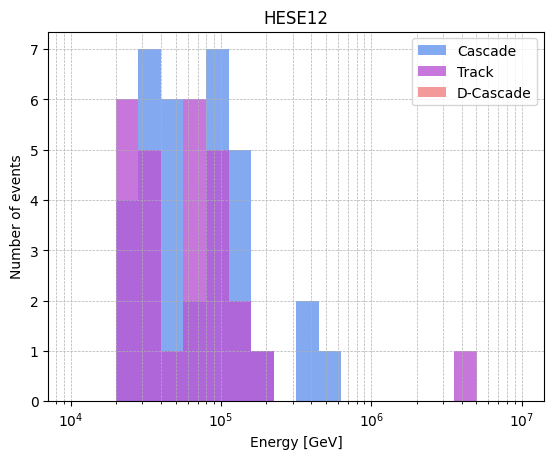

In [11]:
data12 = data_loader.load_data("/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/resources/data/HESE12_data.json", emin=energy_bins[0], emax=energy_bins[-1])
data12 = data12[102:]
print(len(data12))
cascade_energies12 = data12['recoDepositedEnergy'][data12['recoMorphology'] == 0]
track_energies12 = data12['recoDepositedEnergy'][data12['recoMorphology'] == 1]
dcascade_energies12 = data12['recoDepositedEnergy'][data12['recoMorphology'] == 2]

cascade_events_12, _ = np.histogram(cascade_energies12, bins=energy_bins_low_resolution)
track_events_12, _ = np.histogram(track_energies12, bins=energy_bins_low_resolution)
dcascade_events_12, _ = np.histogram(dcascade_energies12, bins=energy_bins_low_resolution)

print(np.sum(cascade_events_12), np.sum(track_events_12), np.sum(dcascade_events_12))


#cascade_df = pd.DataFrame(cascade_events_12, index=bin_centers, columns=['events'])
#track_df = pd.DataFrame(track_events_12, index=bin_centers, columns=['events'])
#dcascade_df = pd.DataFrame(dcascade_events_12, index=bin_centers, columns=['events'])

plt.stairs(cascade_events_12, energy_bins_low_resolution, fill=True, label='Cascade', color='cornflowerblue', alpha=0.8, linewidth=1.6)
plt.stairs(track_events_12, energy_bins_low_resolution, fill=True, label='Track', color='mediumorchid', alpha=0.8, linewidth=1.6)
plt.stairs(dcascade_events_12, energy_bins_low_resolution, fill=True, label='D-Cascade', color='lightcoral', alpha=0.8, linewidth=1.6)
plt.xscale('log') 
#plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
plt.title('HESE12')
plt.legend()
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.5)
plt.show()

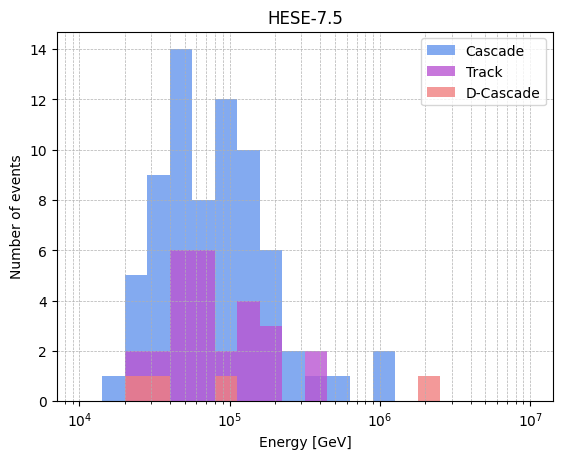

In [83]:


cascade_energies7 = data7['recoDepositedEnergy'][data7['recoMorphology'] == 0]
track_energies7 = data7['recoDepositedEnergy'][data7['recoMorphology'] == 1]
dcascade_energies7 = data7['recoDepositedEnergy'][data7['recoMorphology'] == 2]

cascade_events7, _ = np.histogram(cascade_energies7, bins=energy_bins_low_resolution)
track_events7, _ = np.histogram(track_energies7, bins=energy_bins_low_resolution)
dcascade_events7, _ = np.histogram(dcascade_energies7, bins=energy_bins_low_resolution)

cascade7_df = pd.DataFrame(cascade_events7, index=bin_centers_low_resolution, columns=['events'])
track7_df = pd.DataFrame(track_events7, index=bin_centers_low_resolution, columns=['events'])
dcascade7_df = pd.DataFrame(dcascade_events7, index=bin_centers_low_resolution, columns=['events'])


plt.stairs(cascade_events7, energy_bins_low_resolution, fill=True, label='Cascade', color='cornflowerblue', alpha=0.8, linewidth=1.6)
plt.stairs(track_events7, energy_bins_low_resolution, fill=True, label='Track', color='mediumorchid', alpha=0.8, linewidth=1.6)
plt.stairs(dcascade_events7, energy_bins_low_resolution, fill=True, label='D-Cascade', color='lightcoral', alpha=0.8, linewidth=1.6)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
plt.title('HESE-7.5')
plt.legend()
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.5)
plt.show()

Get the HESE12 events and bin them into the low resolution bins. 

Do the same for the background but using the MC events/weights.

Compute the energy centers, the distance from the centers to the upper and lower edges respectively (used for plotting), and also the full width of the bin (used for computing the flux and its errors).

In [7]:
energies_12 = data12['recoDepositedEnergy']
energies_7 = data7['recoDepositedEnergy']
events_data_12, _ = np.histogram(energies_12, bins=energy_bins_low_resolution)
events_data_7, _ = np.histogram(energies_7, bins=energy_bins_low_resolution)

print(len(energies_12))
print(len(energies_7))


hese12_df = pd.DataFrame(events_data_12, index=bin_centers_low_resolution, columns=['events'])
hese7_df = pd.DataFrame(events_data_7, index=bin_centers_low_resolution, columns=['events'])

# Calculate error bars as distance from center to edges
xerr = [bin_centers_low_resolution - energy_bins_low_resolution[:-1], energy_bins_low_resolution[1:] - bin_centers_low_resolution]

# Compute the full width of the bin
delta_E = np.diff(energy_bins_low_resolution)


#energies_background = mc['recoDepositedEnergy']
#events_background, bin_edges = np.histogram(energies_background, bins=energy_bins_low_resolution, weights=background_weights)
#print(events_background)

164
102


[0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0
 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 0 0 1 1 0 0 0
 1 1 1 1 0 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 0 1 1 1 0 0 1 0 0 0 1 0 1 0 0 0 1 1 1 0 0 0 1 0 1 1 1 1 0
 1 0 0 1 1 0 0 0 1 1 1 0 0 0 0 0]
[0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 2 1 0 2 2 1 1 0 1
 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 2 1 0 1 0 1 0 1 0 0 1 1 0 0 0
 1 1 1 1 0 1 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0]
10 Cascade 1
13 Track 0
20 Cascade 1
28 D-Cascade 0
29 Track 0
31 D-Cascade 0
32 D-Cascade 0
36 Track 0
59 D-Cascade 0
65 Cascade 1
85 Cascade 1
86 Track 0
100 Cascade 1
[28, 31, 32, 59]
[10, 13, 20, 28, 29, 31, 32, 36, 59, 65, 85, 86, 100]
[13, 29, 36, 86]
[10, 20, 65, 85, 100]


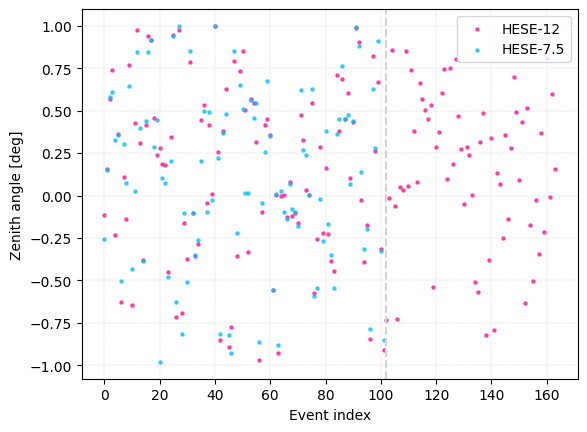

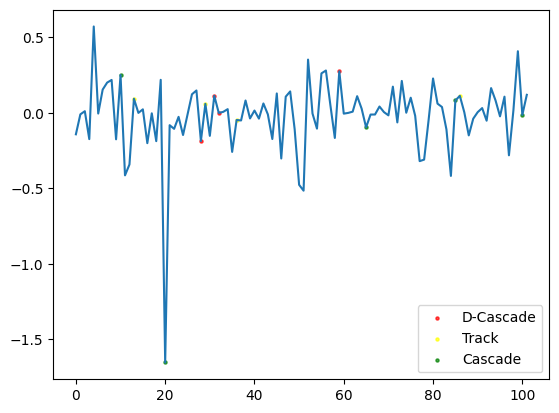

In [17]:
print(data12['recoMorphology'])
print(data7['recoMorphology'])

d_cascade_index = []
track_index = []
cascade_index = []
changed_index = []
for i, M in enumerate(data7['recoMorphology']):
    if M == data12['recoMorphology'][i]:
        pass
    else:
        changed_index.append(i)
        if M == 2:
            print(i, 'D-Cascade', data12['recoMorphology'][i])
            d_cascade_index.append(i)
        elif M == 1:
            print(i, 'Track', data12['recoMorphology'][i])
            track_index.append(i)
        else:
            print(i, 'Cascade', data12['recoMorphology'][i])
            cascade_index.append(i)

print(d_cascade_index)
print(changed_index)
print(track_index)
print(cascade_index)
for i, E in enumerate(energies_12):
    for j, e in enumerate(energies_7):
        if E == e:
            print(i, j)

theta_7 = data7['recoZenith']
theta_12 = data12['recoZenith']

index_12 = range(len(energies_12))
index_7 = range(len(energies_7))
plt.scatter(index_12, np.cos(theta_12), color='deeppink', alpha=0.7, s=5, label='HESE-12')
plt.scatter(index_7, np.cos(theta_7), color='deepskyblue', alpha=0.7, s=5, label='HESE-7.5')
plt.axvline(x=102, linestyle='dashed', color='lightgrey')
#plt.yscale('log')
plt.xlabel('Event index')
plt.ylabel('Zenith angle [deg]')
#plt.title('HESE12 and HESE7.5 event energies')
plt.legend()
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.2)
plt.show()

diff_angle = theta_12[:102] - theta_7

plt.plot(index_12[:102], diff_angle)
plt.scatter(d_cascade_index, diff_angle[d_cascade_index], color='red', alpha=0.7, s=5, label='D-Cascade')
plt.scatter(track_index, diff_angle[track_index], color='yellow', alpha=0.7, s=5, label='Track')
plt.scatter(cascade_index, diff_angle[cascade_index], color='green', alpha=0.7, s=5, label='Cascade')
plt.legend()
plt.show()


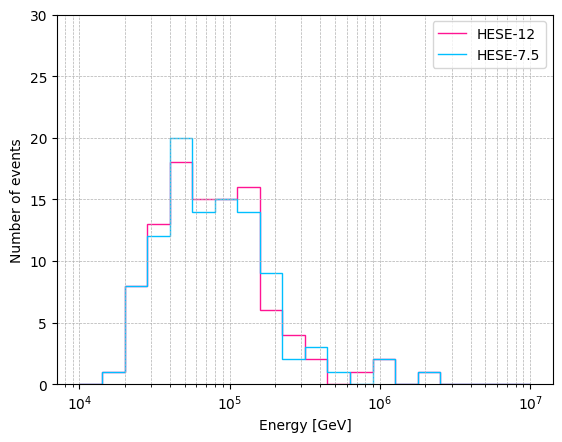

In [48]:
plt.stairs(events_data_12[:101], energy_bins_low_resolution, fill=False, label='HESE-12', color='deeppink', alpha=1)
plt.stairs(events_data_7, energy_bins_low_resolution, fill=False, label='HESE-7.5', color='deepskyblue', alpha=1)
plt.xscale('log')
#plt.yscale('log')
plt.ylim(0, 30)
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
#plt.title('HESE12 Event Distribution')
plt.legend()
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.5)
plt.show()

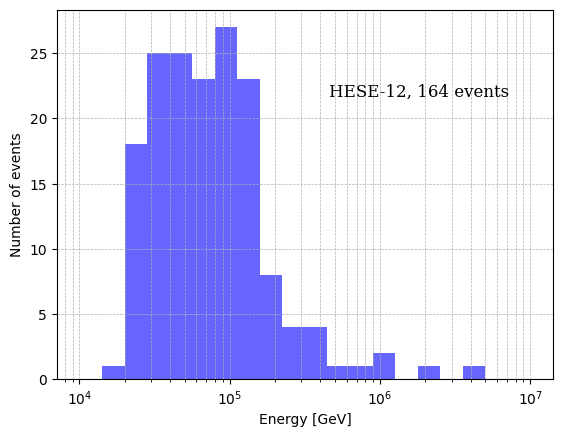

In [70]:
#plt.stairs(events_data_12-events_background, bin_edges, fill=True, color='blue', label='Events')
fig, ax = plt.subplots()
plt.stairs(events_data_12, energy_bins_low_resolution, fill=True, color='blue', label='HESE-12, 164 events', alpha=0.6)

plt.xscale('log')
#plt.yscale('log')
#plt.ylim(4*1e-1, 5*1e2)
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
#plt.title('HESE12 Event Distribution (without background)')
#plt.legend()
fig.text(0.55, 0.7, "HESE-12, 164 events", family='serif', size='large')
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.5)
plt.show()

Plot the event spectrum of the HESE12 data.

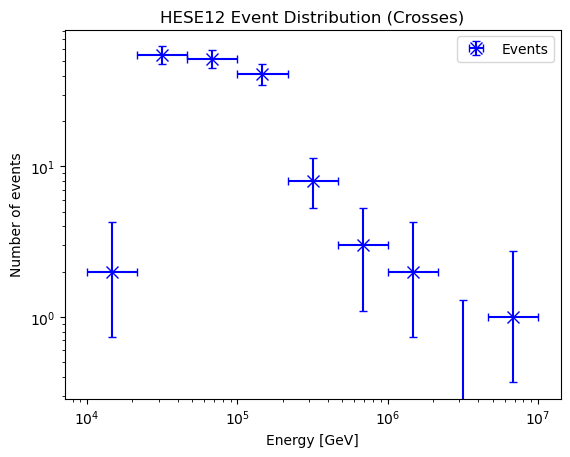

In [39]:

# The error bars are obtained using fc.py, a function writen by Austin Schneider
# and found at https://github.com/austinschneider/feldman_cousins/blob/master/fc.py
one_sigma_proportion = scipy.special.erf(1.0 / np.sqrt(2.0))
yerr = np.array(
    [
        (lambda x: [k - x[0], x[1] - k])(
            fc.poisson_interval(k, alpha=one_sigma_proportion)
        )
        for k in events_data_12
    ]
).T

# Poisson error bars (sqrt(N))
#errors_data_12 = np.sqrt(events_data_12)


plt.errorbar(
    bin_centers, events_data_12, yerr=yerr, xerr=xerr, fmt='x', color='blue', label='Events',
    capsize=3, markersize=8, linestyle='none'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
plt.title('HESE12 Event Distribution (Crosses)')
plt.legend()
plt.show()

Do the same for the scaled MC background.

[2.00759692e+00 3.55201799e+01 1.64462036e+01 5.60388474e+00
 8.97290446e-01 1.19845695e-01 1.00434223e-02 9.52705255e-04
 9.78559825e-05]


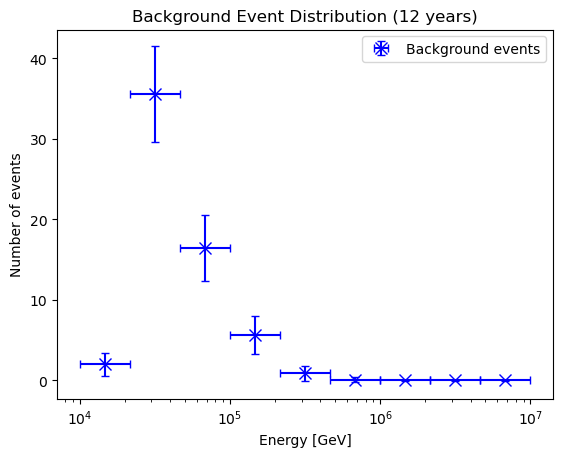

In [81]:
errors_background = np.sqrt(events_background)
print(events_background)

plt.errorbar(
    bin_centers, events_background, yerr=errors_background, xerr=xerr, fmt='x', color='blue', label='Background events',
    capsize=3, markersize=8, linestyle='none'
)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
plt.title('Background Event Distribution (12 years)')
plt.legend()
plt.show()

Get the effective area and bin it.

Take the total area for all flavors as the HESE12 dataset does not contain flavor information.

Possible idea: As HESE12 contain information about shower/track, could be an idea to get the effective area in terms of NC/CC/GR?

In [101]:
eff_df = pd.read_csv('effective_area_4_to_7.csv', index_col=0)
eff_df['total'] = eff_df['nu_e'] + eff_df['nu_mu'] + eff_df['nu_tau']
#energy_edges_old = np.logspace(4, 7, 3*20+1)
energy_centers_old = eff_df.index.values

eff_tot_binned, _ = np.histogram(energy_centers_old, weights=eff_df['total'], bins=energy_bins_low_resolution)
print(eff_tot_binned)




[9.15856936e-02 3.38818375e+00 3.66017140e+01 1.37031892e+02
 2.37691414e+02 4.55399254e+02 7.14555291e+02 8.85414710e+02
 3.29760984e+03]


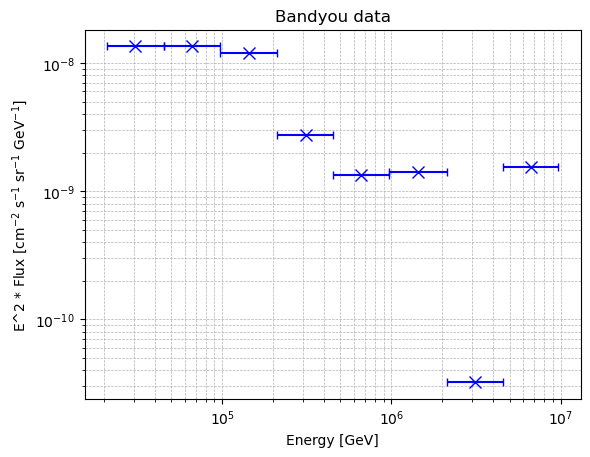

In [88]:
df = pd.read_csv('bandyo_data.csv', header=None)
df.columns = ['energy', 'E^2 * flux']

centers_bandyo = df['energy'].values
edges_bandyo = bin_centers_to_edges(centers_bandyo)
# Calculate error bars as distance from center to edges
xerr_bandyo = [centers_bandyo - edges_bandyo[:-1], edges_bandyo[1:] - centers_bandyo]

# Compute the full width of the bin
#delta_E = np.diff(bin_edges)



plt.errorbar(df['energy'], df['E^2 * flux'], xerr=xerr_bandyo, fmt='x', color='blue', label='Events', capsize=3, markersize=8, linestyle='none')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('E^2 * Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$ GeV$^{-1}$]')
plt.title('Bandyou data')
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.5)
plt.show()

Now compute the flux phi in units [GeV^-1 cm^-1 s^-1 sr^-1].

In [102]:
print(delta_E)

[  11544.34690032   24871.54143581   53584.11166387  115443.46900319
  248715.41435809  535841.11663872 1154434.69003188 2487154.14358089
 5358411.16638723]


/tmp/ipykernel_999/3750817697.py:4: RuntimeWarning: invalid value encountered in divide
  flux_err = flux / np.sqrt(events_data_12)


[4.32814636e-05 1.37118267e-04 5.11448020e-05 4.59051894e-05
 2.20077718e-05 1.83581334e-05 3.32425046e-05 0.00000000e+00
 6.54184591e-05]


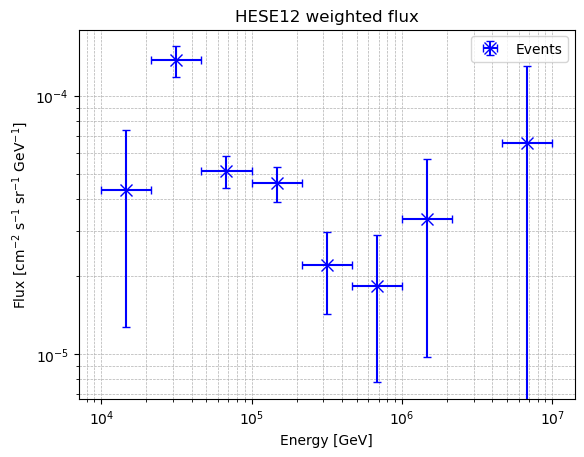

In [108]:

# Factor of 1e4 to convert from m^2 to cm^2
flux = events_data_12 / (delta_E * eff_tot_binned * livetime12 * 4*np.pi * 1e4)

flux_err = flux / np.sqrt(events_data_12)

si = 2.8888
yerr = bin_centers**si * flux_err
print(bin_centers**si * flux)

plt.errorbar(bin_centers, bin_centers**si * flux, xerr=xerr, yerr=yerr, fmt='x', color='blue', label='Events', capsize=3, markersize=8, linestyle='none')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$ GeV$^{-1}$]')
plt.title('HESE12 weighted flux')
plt.legend()
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.5)
plt.show()






Remove the scaled MC background from the HESE12 data.

/tmp/ipykernel_999/1885945325.py:3: RuntimeWarning: invalid value encountered in sqrt
  errors_data_no_background = np.sqrt(data_no_background)


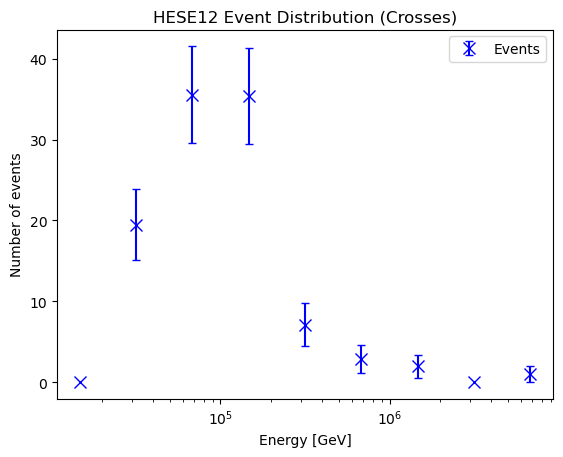

In [46]:



data_no_background = events_data_12 - events_background

errors_data_no_background = np.sqrt(data_no_background)

plt.errorbar(
    bin_centers, data_no_background, yerr=errors_data_no_background, fmt='x', color='blue', label='Events',
    capsize=3, markersize=8, linestyle='none'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
plt.title('HESE12 Event Distribution (without background)')
plt.legend()
plt.show()


/tmp/ipykernel_999/4205588815.py:4: RuntimeWarning: invalid value encountered in sqrt
  flux_err = flux_no_background / np.sqrt(data_no_background)


[-3.25518887e-11  4.86090987e-09  1.76936517e-09  1.01367840e-09
  2.52644671e-10  1.15201028e-10  1.09288385e-10 -9.09727680e-14
  5.52320475e-11]


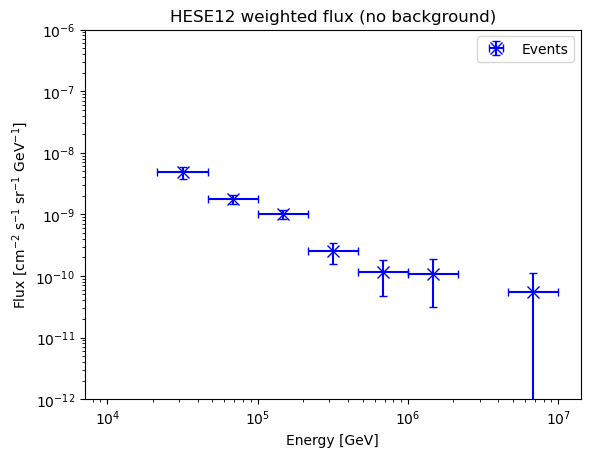

In [51]:

# Factor of 1e4 to convert from m^2 to cm^2
flux_no_background = data_no_background / (delta_E * eff_tot_binned * livetime12 * 4*np.pi * 1e4)

flux_err = flux_no_background / np.sqrt(data_no_background)

si = 2.0
err_tot = bin_centers**si * flux_err
print(bin_centers**si * flux_no_background)

plt.errorbar(bin_centers, bin_centers**si * flux_no_background, xerr=xerr, yerr=err_tot, fmt='x', color='blue', label='Events', capsize=3, markersize=8, linestyle='none')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-12, 1e-6)
plt.xlabel('Energy [GeV]')
plt.ylabel('Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$ GeV$^{-1}$]')
plt.title('HESE12 weighted flux (no background)')
plt.legend()
plt.show()

In [48]:
print(flux_no_background)

[-1.51092483e-19  4.86090987e-18  3.81198169e-19  4.70507837e-20
  2.52644671e-21  2.48193092e-22  5.07271747e-23 -9.09727680e-27
  1.18993839e-24]
